In [8]:
import pandas as pd
import numpy as np

from market_data import MarketData
from data_processor import DataProcessor
from calculate_indicators import Calculate
from trading_strategy import TradingStrategy

# **1. Download Data**

In [9]:
tickers = [
    # Technology (Công nghệ)
    "AAPL","MSFT","GOOGL","AMZN","META",
    "NVDA","AMD","INTC","AVGO",
    "ADBE","CRM","ORCL","IBM",
    "SAP","ASML","QCOM","TXN",
    "UBER","SHOP","XYZ","NFLX","SONY",
    "INTU","ADSK","SNOW",

    # Financials (Tài chính – ngân hàng – đầu tư)
    "JPM","BAC","WFC","C",
    "GS","MS","BRK-A","BRK-B",
    "V","MA","PYPL","AXP",
    "SCHW","BLK","HSBC","RY",
    "CME","BK",

    # Consumer (Tiêu dùng – bán lẻ – giải trí)
    "WMT","COST","HD","TGT",
    "MCD","SBUX","KO","PEP",
    "PG","UL","DEO","PM",
    "NKE","DIS","CMG","TSM",
    "EA","TTWO","RBLX",
    "MGM","YUM",

    # Industrials (Công nghiệp – vận tải – quốc phòng)
    "CAT","DE","BA","LMT",
    "UPS","FDX","GE","HON",
    "MMM","RTX","NOC","GD",
    "EMR",

    # Energy & Materials (Năng lượng – nguyên vật liệu)
    "XOM","CVX","BP","SHEL",
    "COP","SLB","HAL","EOG",
    "LIN","APD","SHW","FCX","NUE",

    # Healthcare (Y tế – dược phẩm – bảo hiểm y tế)
    "JNJ","PFE","MRK","ABT","ABBV",
    "UNH","CVS","TMO","BMY","AMGN"
]

len(tickers)

100

In [10]:
market = MarketData(tickers)
market.download_data(start_date = "2010-01-01", end_date = "2025-10-11")

[*********************100%***********************]  100 of 100 completed


Price        Adj Close                                                  \
Ticker            AAPL        ABBV         ABT        ADBE        ADSK   
Date                                                                     
2010-01-04    6.418382         NaN   18.414780   37.090000   25.670000   
2010-01-05    6.429478         NaN   18.266006   37.700001   25.280001   
2010-01-06    6.327210         NaN   18.367445   37.619999   25.340000   
2010-01-07    6.315514         NaN   18.519611   36.889999   25.480000   
2010-01-08    6.357501         NaN   18.614286   36.689999   26.260000   
...                ...         ...         ...         ...         ...   
2025-10-06  256.441406  228.542419  133.147934  350.140015  323.429993   
2025-10-07  256.231628  231.163513  132.431122  348.309998  314.190002   
2025-10-08  257.810089  229.584900  133.675583  348.769989  311.410004   
2025-10-09  253.793961  229.038834  132.719818  347.470001  310.320007   
2025-10-10  245.032471  228.850189  131.983109  337.510010  303.500000   

Price                                                                    ...  \
Ticker             AMD        AMGN        AMZN         APD         ASML  ...   
Date                                                                     ...   
2010-01-04    9.700000   39.311672    6.695000   51.808636    32.425724  ...   
2010-01-05    9.710000   38.971142    6.734500   51.378777    32.678322  ...   
2010-01-06    9.570000   38.678268    6.612500   50.955139    32.977692  ...   
2010-01-07    9.470000   38.324116    6.500000   50.662342    32.060871  ...   
2010-01-08    9.430000   38.664658    6.676000   50.986298    31.293718  ...   
...                ...         ...         ...         ...          ...  ...   
2025-10-06  203.710007  292.037079  220.899994  270.950012  1041.452271  ...   
2025-10-07  211.509995  293.447021  221.779999  270.890015  1000.524902  ...   
2025-10-08  235.559998  292.533539  225.220001  268.579987   986.060547  ...   
2025-10-09  232.889999  293.337799  227.740005  262.709991   978.803406  ...   
2025-10-10  214.899994  288.075348  216.369995  257.079987   934.531982  ...   

Price           Volume                                                   \
Ticker            UBER       UL       UNH       UPS         V       WFC   
Date                                                                      
2010-01-04         NaN   799200  12199500   3897200  20180000  39335700   
2010-01-05         NaN   929500  11180700   5966300  25833600  55416000   
2010-01-06         NaN  1811600   9761100   5770200  16254000  33237000   
2010-01-07         NaN  1365300  11789800   5747000  27841200  61649000   
2010-01-08         NaN   761700   7228700  13779300  11907200  35508700   
...                ...      ...       ...       ...       ...       ...   
2025-10-06  22760900.0  2028600   7181700   6987000   4735600  12837700   
2025-10-07  12583600.0  2186600   7236200   4726800   5044600  10371300   
2025-10-08  10071200.0  1821300   9438300   4896000   3927500  11277400   
2025-10-09  13435700.0  2520000   8759800   5784700   4434800   8432200   
2025-10-10  17021100.0  5310800  13141900   8506000   6296200  16004300   

Price                                               
Ticker           WMT       XOM        XYZ      YUM  
Date                                                
2010-01-04  62259300  27809100        NaN  2962274  
2010-01-05  46945200  30174700        NaN  3298757  
2010-01-06  37551600  35044700        NaN  4178981  
2010-01-07  31988100  27192100        NaN  2452472  
2010-01-08  34089600  24891800        NaN  3772392  
...              ...       ...        ...      ...  
2025-10-06  13303600  12036800  5324100.0  1395000  
2025-10-07  15538900  11945000  5428000.0  1657100  
2025-10-08  13584100  12301000  6024900.0  1150600  
2025-10-09  19508000  10976200  4193600.0  1371000  
2025-10-10  18519400  13811600  8802300.0  2055300  

[3968 rows x 600 columns]

In [11]:
market.save_df(filename='price_volume_data.csv')

# **2. Data Preparation and Outlier Handling**

In [40]:
import os 
os.chdir(r"C:\Users\Admin\Downloads\scripts")
#os.chdir(r"C:\Users\Admin\Downloads")

In [41]:
import pandas as pd
import numpy as np
from calculate_indicators import Calculate
from data_processor import DataProcessor

In [42]:
os.chdir(r"C:\Users\Admin\Downloads")

In [43]:
data = pd.read_csv("price_volume_data.csv", header=[0, 1], index_col=0, parse_dates=True)
data.head()

Price      Adj Close                                                         \
Ticker          AAPL ABBV        ABT       ADBE       ADSK   AMD       AMGN   
Date                                                                          
2010-01-04  6.424605  NaN  18.414782  37.090000  25.670000  9.70  39.592060   
2010-01-05  6.435713  NaN  18.266008  37.700001  25.280001  9.71  39.249092   
2010-01-06  6.333344  NaN  18.367441  37.619999  25.340000  9.57  38.954151   
2010-01-07  6.321635  NaN  18.519604  36.889999  25.480000  9.47  38.597458   
2010-01-08  6.363664  NaN  18.614286  36.689999  26.260000  9.43  38.940434   

Price                                     ... Volume                     \
Ticker        AMZN        APD       ASML  ...   UBER       UL       UNH   
Date                                      ...                             
2010-01-04  6.6950  51.808655  32.425728  ...    NaN   799200  12199500   
2010-01-05  6.7345  51.378773  32.678314  ...    NaN   929500  11180700   
2010-01-06  6.6125  50.955124  32.977688  ...    NaN  1811600   9761100   
2010-01-07  6.5000  50.662312  32.060867  ...    NaN  1365300  11789800   
2010-01-08  6.6760  50.986294  31.293720  ...    NaN   761700   7228700   

Price                                                                      
Ticker           UPS         V       WFC       WMT       XOM XYZ      YUM  
Date                                                                       
2010-01-04   3897200  20180000  39335700  62259300  27809100 NaN  2962274  
2010-01-05   5966300  25833600  55416000  46945200  30174700 NaN  3298757  
2010-01-06   5770200  16254000  33237000  37551600  35044700 NaN  4178981  
2010-01-07   5747000  27841200  61649000  31988100  27192100 NaN  2452472  
2010-01-08  13779300  11907200  35508700  34089600  24891800 NaN  3772392  

[5 rows x 600 columns]

In [44]:
prepare = DataProcessor("price_volume_data.csv")

# for ticker in prepare.tickers:
#     prepare.check_na(ticker)

prepare.add_log_returns()

prepare.winsorize_data()

prepare.save_cleaned_data("cleaned_price_volume_data.csv")

# for ticker in tickers:
#     prepare.draw_boxplot(ticker, 'Return')

# for ticker in tickers:
#     prepare.draw_histogram(ticker, 'Return')

In [45]:
c = Calculate("cleaned_price_volume_data.csv")
c.add_indicators()

c.df.to_csv("price_volume_indicators_data.csv")

# c.calculate_position_size()

print(set(c.df.columns.get_level_values(0)))
c.df.tail()

{'Low', 'Close', 'SMA_50', 'High', 'Open', 'Volume', 'Volatility', 'Log Return', 'SMA_200', 'Adj Close'}


Adj Close                                                  \
Ticker            AAPL        ABBV         ABT        ADBE        ADSK   
Date                                                                     
2025-10-06  256.690002  228.542419  133.147934  350.140015  323.429993   
2025-10-07  256.480011  231.163513  132.431122  348.309998  314.190002   
2025-10-08  258.059998  229.584900  133.675583  348.769989  311.410004   
2025-10-09  254.039993  229.038834  132.719818  347.470001  310.320007   
2025-10-10  245.270004  228.850189  131.983109  337.510010  303.500000   

                                                                         ...  \
Ticker             AMD        AMGN        AMZN         APD         ASML  ...   
Date                                                                     ...   
2025-10-06  203.710007  294.119995  220.899994  270.950012  1041.452271  ...   
2025-10-07  211.509995  295.540009  221.779999  270.890015  1000.524902  ...   
2025-10-08  235.559998  294.619995  225.220001  268.579987   986.060547  ...   
2025-10-09  232.889999  295.429993  227.740005  262.709991   978.803406  ...   
2025-10-10  214.899994  290.130005  216.369995  257.079987   934.531982  ...   

           Volatility                                                    \
Ticker           UBER        UL       UNH       UPS         V       WFC   
Date                                                                      
2025-10-06   0.340511  0.114899  0.251534  0.158889  0.187511  0.184932   
2025-10-07   0.332844  0.116156  0.250673  0.158124  0.189086  0.185560   
2025-10-08   0.334374  0.110913  0.207018  0.158309  0.189214  0.182772   
2025-10-09   0.352972  0.114522  0.208329  0.162004  0.184012  0.182012   
2025-10-10   0.365892  0.142903  0.240623  0.188054  0.179869  0.201537   

                                                    
Ticker           WMT       XOM       XYZ       YUM  
Date                                                
2025-10-06  0.145097  0.191584  0.329469  0.199246  
2025-10-07  0.133365  0.191213  0.331345  0.189073  
2025-10-08  0.133994  0.190642  0.340763  0.182260  
2025-10-09  0.122750  0.186059  0.327480  0.199029  
2025-10-10  0.094926  0.197964  0.437527  0.182778  

[5 rows x 1000 columns]

In [46]:
import os
os.chdir(r'C:\Users\Admin\Downloads\scripts\CF_Ngan23280071_Dung23280048')

# **3. Trading Strategy**

In [47]:
from trading_strategy import TradingStrategy
from matplotlib import pyplot as plt
from plot import Plot

In [48]:
strategy = TradingStrategy("price_volume_indicators_data.csv")
print(set(strategy.df.columns.get_level_values(0)))

{'Low', 'Close', 'SMA_50', 'High', 'Open', 'Volume', 'Volatility', 'Log Return', 'SMA_200', 'Adj Close'}


## **3.1. Momentum Strategy**

In [49]:
strategy.momentum_signal()
strategy.apply_position_sizing()

In [50]:
print(set(strategy.df.columns.get_level_values(0)))

{'Low', 'Close', 'SMA_50', 'Signal', 'Position Size', 'High', 'Open', 'Volume', 'Volatility', 'Log Return', 'SMA_200', 'Adj Close'}


In [51]:
strategy.get_actions().sort_values(by=['Value_Est'], ascending=False).head(10)

Ngày giao dịch: 2025-10-10


,Ticker,Action,Shares,Price_Est,Value_Est
9,CME,BUY,54,268.839996,14517.359802
60,UPS,SELL,145,85.279999,12365.599823
43,PEP,BUY,82,144.710007,11866.220551
2,AMZN,BUY,43,227.740005,9792.820236
38,MMM,SELL,61,152.880005,9325.680298
13,CRM,BUY,31,245.330002,7605.230057
5,BA,SELL,34,216.000000,7344.000000
25,HON,BUY,8,192.488220,1539.905762
48,RTX,SELL,9,162.179993,1459.619934
4,AVGO,BUY,4,345.019989,1380.079956


In [52]:
long_df, short_df = strategy.get_portfolio(top_n=10)
long_df.head(10)

Ngày giao dịch: 2025-10-10


,Ticker,Price,Volatility,Action,Shares,Value
0,RY,143.639999,0.092477,LONG,79,11347.559952
1,BRK-B,489.130005,0.098613,LONG,21,10271.730103
5,WMT,101.839996,0.094926,LONG,80,8147.199707
6,JPM,300.890015,0.119291,LONG,27,8124.030396
8,LMT,505.049988,0.127377,LONG,15,7575.749817
9,BAC,48.650002,0.147086,LONG,150,7297.500229
10,CME,271.450012,0.139318,LONG,26,7057.700317
11,BK,104.026932,0.153075,LONG,66,6865.777496
15,JNJ,190.720001,0.142364,LONG,35,6675.200043
16,GD,332.940002,0.166951,LONG,19,6325.860046


In [53]:
short_df.head(10)

,Ticker,Price,Volatility,Action,Shares,Value
2,UL,60.430000,0.142903,SHORT,-148,8943.640045
3,KO,67.040001,0.119880,SHORT,-131,8782.240120
4,MCD,297.010010,0.121652,SHORT,-28,8316.280273
7,DIS,109.190002,0.121242,SHORT,-74,8080.060181
12,HON,189.359100,0.133756,SHORT,-36,6816.927612
13,HD,375.750000,0.097521,SHORT,-18,6763.500000
14,PG,148.650497,0.143569,SHORT,-45,6689.272385
17,CVX,148.899994,0.163652,SHORT,-42,6253.799744
19,DEO,93.237335,0.164402,SHORT,-66,6153.664124
22,UPS,82.870003,0.188054,SHORT,-72,5966.640198


In [54]:
from plot import Plot

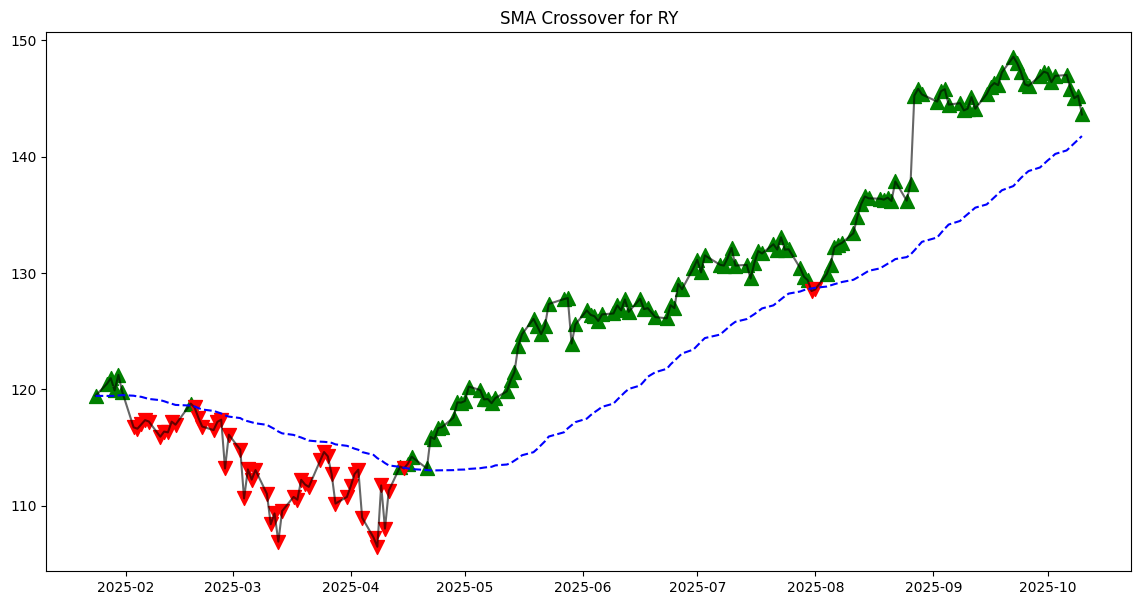

In [55]:
plot_object = Plot(strategy.df)
plot_object.plot_short_time(strategy_name='momentum', ticker='RY', time=180, plot_signals=True)

In [56]:
print(long_df.columns)

Index(['Ticker', 'Price', 'Volatility', 'Action', 'Shares', 'Value'], dtype='object')


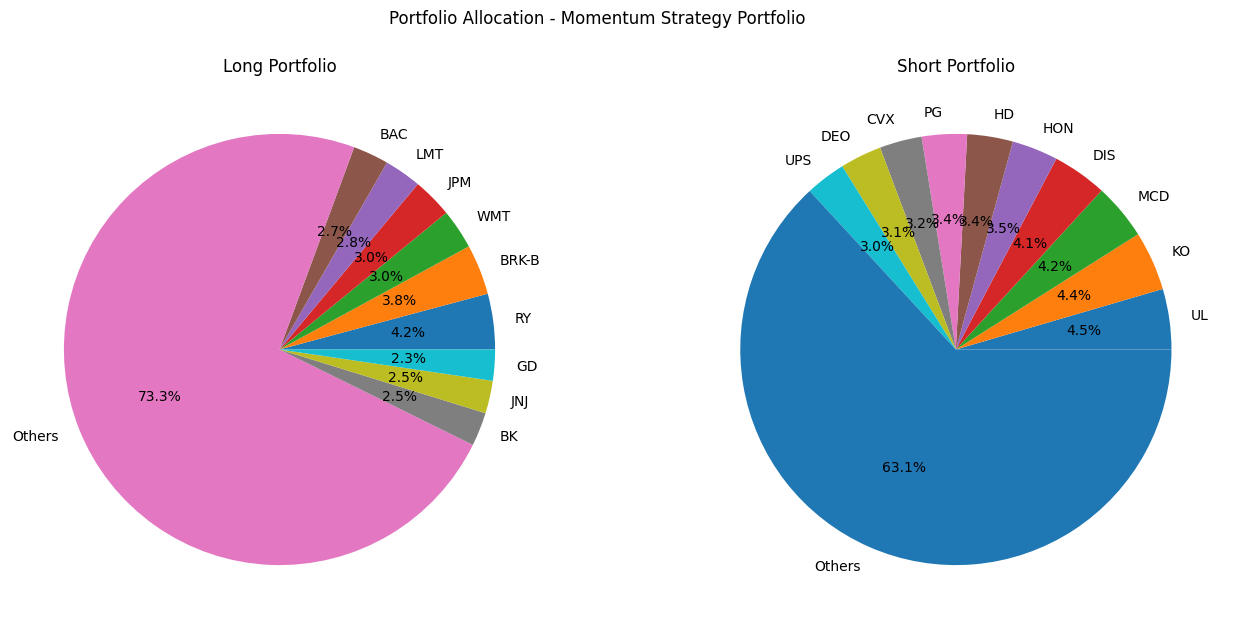

Index(['Ticker', 'Price', 'Volatility', 'Action', 'Shares', 'Value'], dtype='object')


In [57]:
# plt.figure(figsize=(8, 8))
# plt.pie(momentum_portfolio['Value'], labels=momentum_portfolio['Ticker'], autopct='%1.1f%%')
# plt.title('Momentum Strategy Portfolio')
# plt.show()
plot_object = Plot(strategy.df)
plot_object.plot_porfolio(long_df, short_df, 'Momentum Strategy Portfolio')
print(short_df.columns)

## **3.2. Mean Reversion Strategy**

In [58]:
from trading_strategy import TradingStrategy
from plot import Plot

In [59]:
print(set(strategy.df.columns.get_level_values(0)))

{'Low', 'Close', 'SMA_50', 'Signal', 'Position Size', 'High', 'Open', 'Volume', 'Volatility', 'Log Return', 'SMA_200', 'Adj Close'}


In [60]:
strategy.mean_reversion_signal()
strategy.apply_position_sizing()

C:\Users\Admin\Downloads\scripts\CF_Ngan23280071_Dung23280048\trading_strategy.py:88: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  self.df = self.df.drop(columns=['Position Size'])


In [61]:
strategy.get_actions().sort_values(by=['Value_Est'], ascending=False).head(10)

Ngày giao dịch: 2025-10-10


,Ticker,Action,Shares,Price_Est,Value_Est
2,HON,BUY,36,192.488220,6929.575928
1,HD,BUY,18,377.690002,6798.420044
4,LIN,BUY,13,458.160004,5956.080048
7,NOC,BUY,9,635.010010,5715.090088
8,PEP,SELL,36,144.710007,5209.560242
15,YUM,BUY,35,142.690002,4994.150085
13,UNH,BUY,13,367.690002,4779.970032
3,HSBC,BUY,67,67.330002,4511.110123
12,SLB,BUY,123,33.130001,4074.990131
0,BA,BUY,18,216.000000,3888.000000


In [62]:
long_df, short_df = strategy.get_portfolio()
long_df

Ngày giao dịch: 2025-10-10


,Ticker,Price,Volatility,Action,Shares,Value
0,MCD,297.010010,0.121652,LONG,28,8316.280273
1,HON,189.359100,0.133756,LONG,36,6816.927612
2,HD,375.750000,0.097521,LONG,18,6763.500000
3,LIN,453.820007,0.143880,LONG,13,5899.660095
4,ADSK,303.500000,0.184758,LONG,18,5463.000000
6,YUM,141.619995,0.182778,LONG,35,4956.699829
7,HSBC,65.919998,0.228632,LONG,67,4416.639877
8,SLB,31.719999,0.279441,LONG,123,3901.559916
9,SBUX,78.459999,0.264648,LONG,48,3766.079956


In [63]:
short_df

,Ticker,Price,Volatility,Action,Shares,Value
5,PEP,150.080002,0.209121,SHORT,-36,5402.880066
10,PYPL,69.839996,0.396527,SHORT,-41,2863.439850
11,SNOW,242.169998,0.437360,SHORT,-9,2179.529984
12,AMD,214.899994,0.614138,SHORT,-8,1719.199951


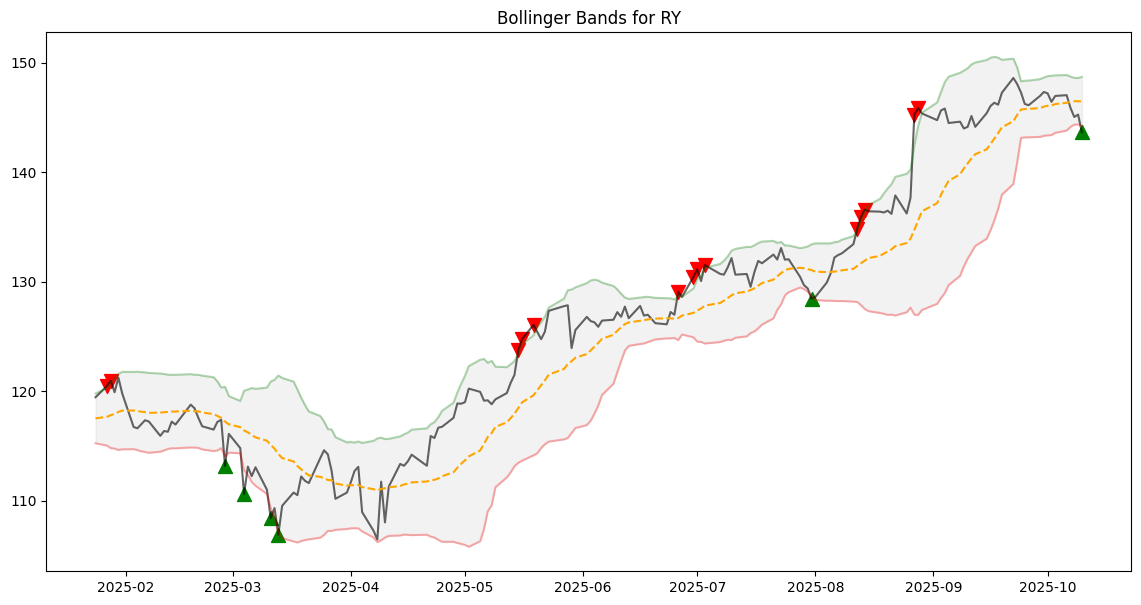

In [64]:
plot_object = Plot(strategy.df)
plot_object.plot_short_time(strategy_name='mean_reversion', ticker='RY', time=180, plot_signals=True)

In [65]:
print(set(strategy.df.columns.get_level_values(0)))

{'Low', 'Close', 'SMA_50', 'Signal', 'BB_Upper', 'Position Size', 'High', 'BB_Lower', 'Open', 'Volume', 'BB_Mean', 'Volatility', 'Log Return', 'SMA_200', 'Adj Close'}


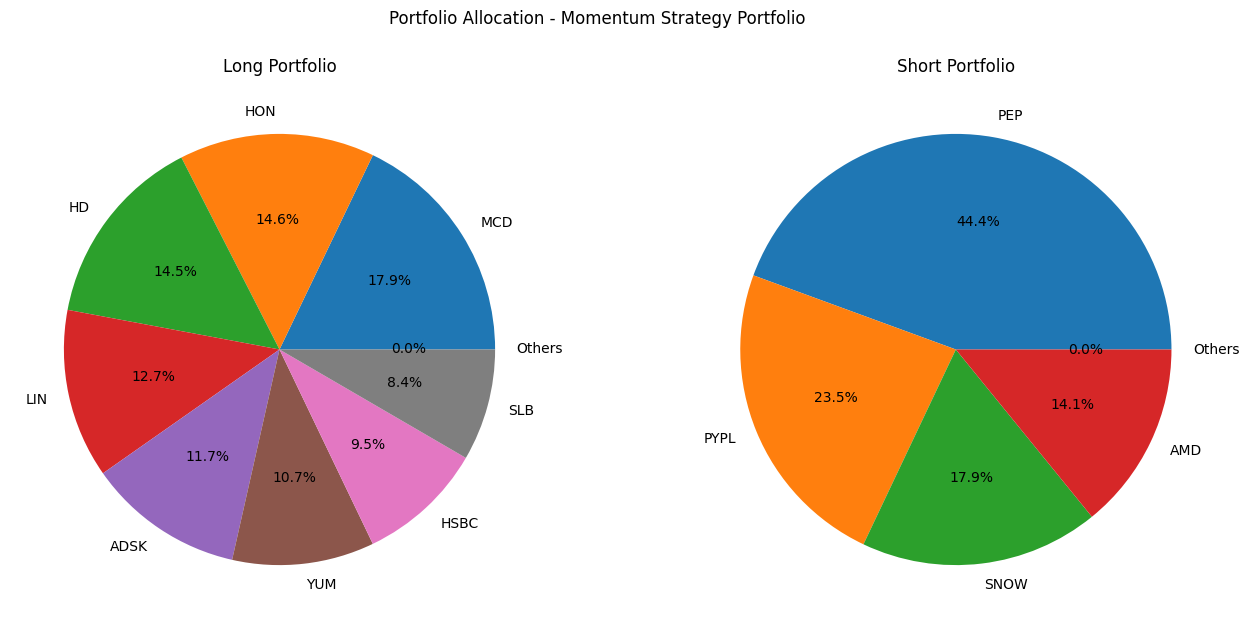

Index(['Ticker', 'Price', 'Volatility', 'Action', 'Shares', 'Value'], dtype='object')


In [66]:



plot_object = Plot(strategy.df)
plot_object.plot_porfolio(long_df, short_df, 'Momentum Strategy Portfolio')
print(short_df.columns)